# Wing Comparative Aerodynamics — XFLR5 Analysis
**Document:** Wing Configuration Analysis  
**Author:** Colin Y. Cooper  
**Tool:** XFLR5 v6.62 — Wing and Plane Desgin (3D)  
**Freestream Speed:** 22 m/s (79.2 km/h)  
**Reynolds Numbers:** 100,000 / 200,000 / 300,000  

---

## Overview

This notebook presents the complete aerodynamic analysis pipeline for airfoil selection for the Modular Wing Comparative Aerodynamics flight test program. This analysis is the **second** of two phases:

**Phase 1 — 2D Airfoil Analysis**  
XFoil polar analysis of three candidate airfoils (MH45, NACA 0009, E214) across the operating Reynolds number range. Used for airfoil selection and pre-test prediction of section aerodynamic coefficients.

**Phase 2 — 3D Wing Configuration Analysis**  
Vortex Lattice Method (VLM2) analysis of three wing configurations at cruise speed. Quantifies induced drag contribution, lift curve characteristics, and pitching moment behavior for each test configuration.

---

## 1. Setup

In [10]:
# Setup Workspace 
# Initialize libraries 
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

# Initialize plotting parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'legend.framealpha': 0.9,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

# Import Wing Data 
wing_a = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\WING-A_NACA0009_AR5_VLM.csv')
wing_b = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\WING-B_MH45_AR5_VLM.csv')
wing_c = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\WING-C_MH45_AR7_VLM.csv')

# Insert Lift/Drag ratio into datasets 
wing_a['CL/CD'] = wing_a['CL']/wing_a['CD']
wing_b['CL/CD'] = wing_b['CL']/wing_b['CD']
wing_c['CL/CD'] = wing_c['CL']/wing_c['CD']


    alpha        CL       CDi       CDv        CD        Cm     XCP      CL/CD
0    -6.0 -0.396938  0.010165  0.008874  0.019039  0.306609  0.1395 -20.848679
1    -5.5 -0.364122  0.008554  0.008532  0.017086  0.281365  0.1394 -21.311132
2    -5.0 -0.331238  0.007079  0.008319  0.015398  0.256047  0.1393 -21.511755
3    -4.5 -0.298292  0.005741  0.008260  0.014001  0.230662  0.1393 -21.305050
4    -4.0 -0.265290  0.004541  0.008232  0.012773  0.205209  0.1392 -20.769592
5    -3.5 -0.232238  0.003480  0.008278  0.011758  0.179697  0.1392 -19.751488
6    -3.0 -0.199142  0.002559  0.008331  0.010890  0.154130  0.1392 -18.286685
7    -2.5 -0.166009  0.001778  0.008401  0.010179  0.128516  0.1391 -16.308969
8    -2.0 -0.132845  0.001139  0.008477  0.009616  0.102862  0.1391 -13.814996
9    -1.5 -0.099655  0.000641  0.008551  0.009192  0.077175  0.1391 -10.841493
10   -1.0 -0.066447  0.000285  0.008597  0.008882  0.051464  0.1391  -7.481085
11   -0.5 -0.033227  0.000071  0.008626  0.008697  0

## 2. Lift Curve Comparison 

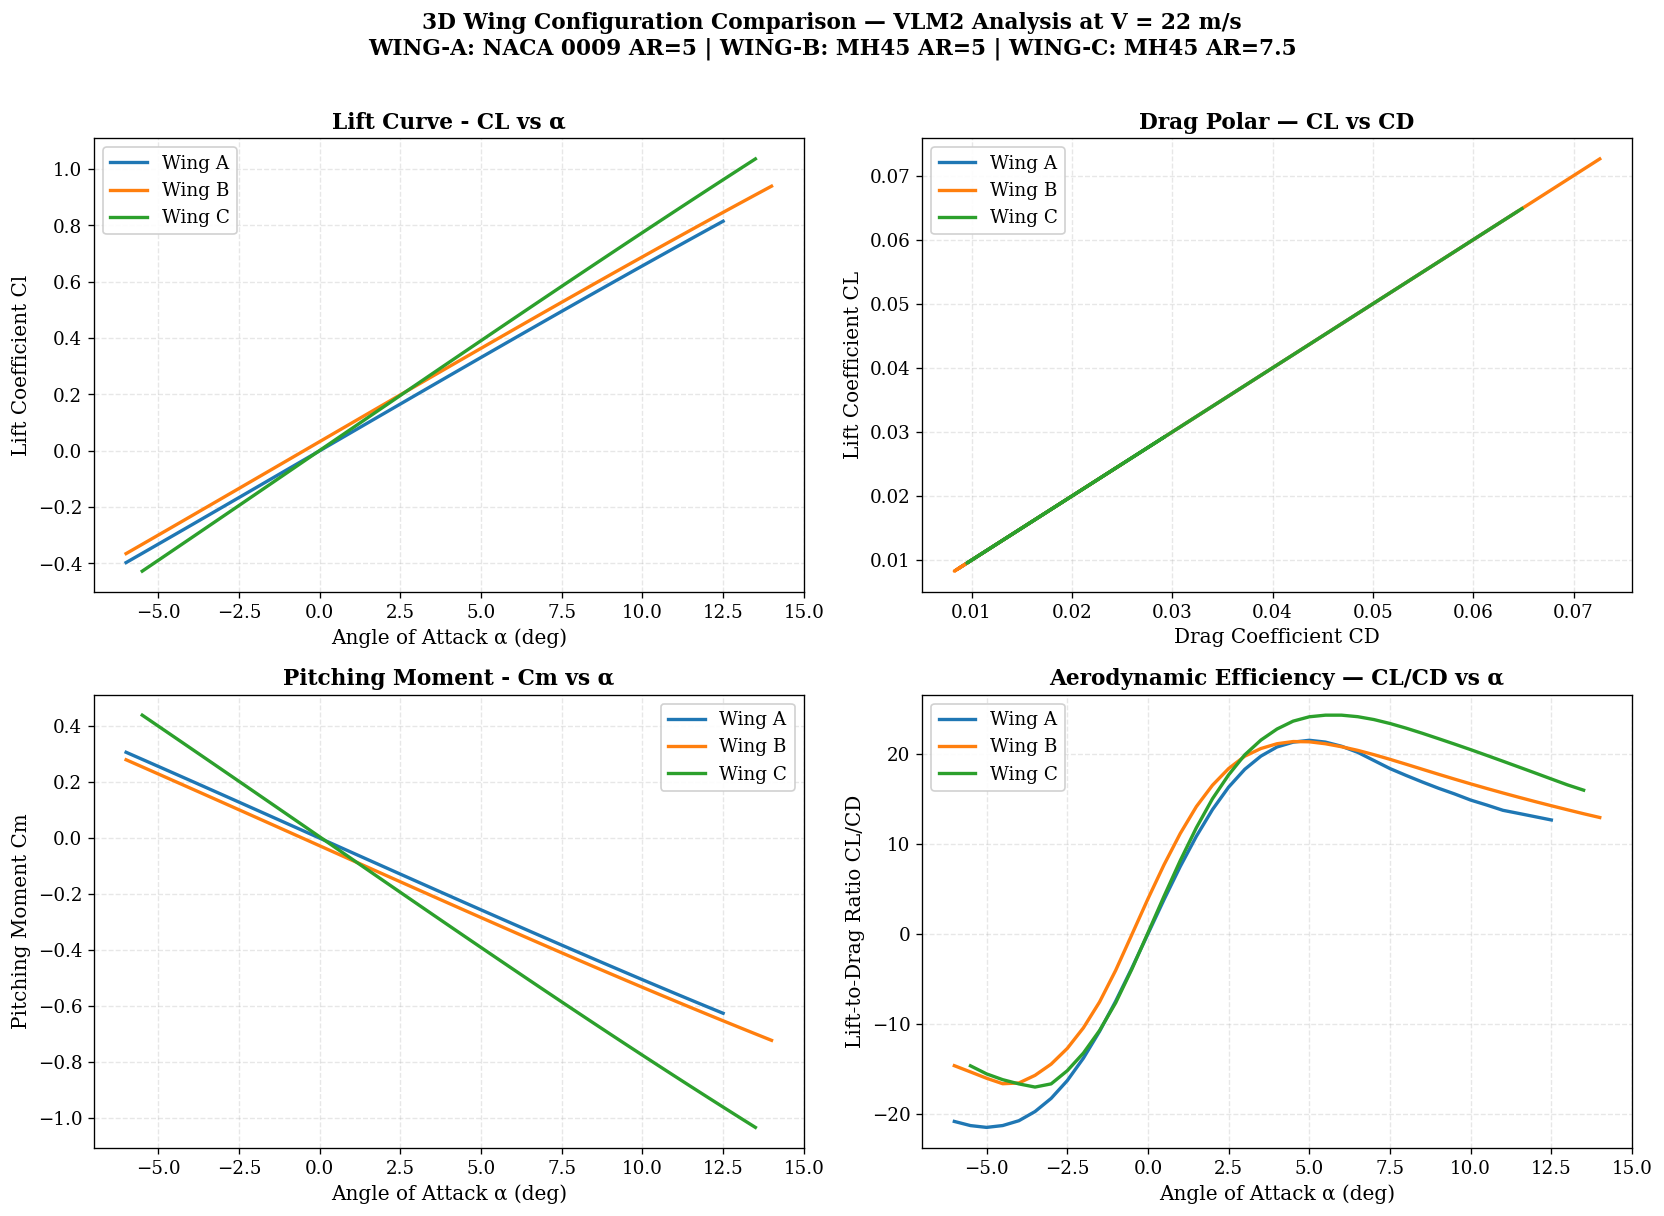

In [8]:
## Initialize figure 
fig, axes = plt.subplots(2,2, figsize = (14,10))
fig.suptitle('3D Wing Configuration Comparison — VLM2 Analysis at V = 22 m/s\n'
             'WING-A: NACA 0009 AR=5 | WING-B: MH45 AR=5 | WING-C: MH45 AR=7.5',
             fontsize=13, fontweight='bold', y=1.01)

# Initialize subplot 
ax_cl_a  = axes[0, 0]  # CL vs Alpha
ax_polar = axes[0, 1]  # CL vs CD (drag polar)
ax_cm    = axes[1, 0]  # Cm vs Alpha
ax_ld    = axes[1, 1]  # CL/CD vs alpha

# --- Plot Lift coefficient against AoA ---
ax_cl_a.plot(wing_a['alpha'],wing_a['CL'], label = 'Wing A')
ax_cl_a.plot(wing_b['alpha'],wing_b['CL'], label = 'Wing B')
ax_cl_a.plot(wing_c['alpha'],wing_c['CL'], label = 'Wing C')
ax_cl_a.set_xlabel('Angle of Attack α (deg)')
ax_cl_a.set_ylabel('Lift Coefficient Cl')
ax_cl_a.set_title('Lift Curve - CL vs α')
ax_cl_a.legend()

# --- Plot Drag Polar ---
ax_polar.plot(wing_a['CD'],wing_a['CD'], label = 'Wing A')
ax_polar.plot(wing_b['CD'],wing_b['CD'], label = 'Wing B')
ax_polar.plot(wing_c['CD'],wing_c['CD'], label = 'Wing C')
ax_polar.set_xlabel('Drag Coefficient CD')
ax_polar.set_ylabel('Lift Coefficient CL')
ax_polar.set_title('Drag Polar — CL vs CD')
ax_polar.legend()

# --- Plot lift/drag against AoA ---
ax_ld.plot(wing_a['alpha'],wing_a['CL/CD'], label = 'Wing A')
ax_ld.plot(wing_b['alpha'],wing_b['CL/CD'], label = 'Wing B')
ax_ld.plot(wing_c['alpha'],wing_c['CL/CD'], label = 'Wing C')
ax_ld.set_xlabel('Angle of Attack α (deg)')
ax_ld.set_ylabel('Lift-to-Drag Ratio CL/CD')
ax_ld.set_title('Aerodynamic Efficiency — CL/CD vs α')
ax_ld.legend()

# --- Plot pitching moment against AoA ---
ax_cm.plot(wing_a['alpha'],wing_a['Cm'], label = 'Wing A') 
ax_cm.plot(wing_b['alpha'],wing_b['Cm'], label = 'Wing B') 
ax_cm.plot(wing_c['alpha'],wing_c['Cm'], label = 'Wing C') 
ax_cm.set_xlabel('Angle of Attack α (deg)')
ax_cm.set_ylabel('Pitching Moment Cm')
ax_cm.set_title('Pitching Moment - Cm vs α')
ax_cm.legend()
              
# Display figure
plt.tight_layout()
plt.show()

## 3. Drag Breakdown - Induced vs Viscous 

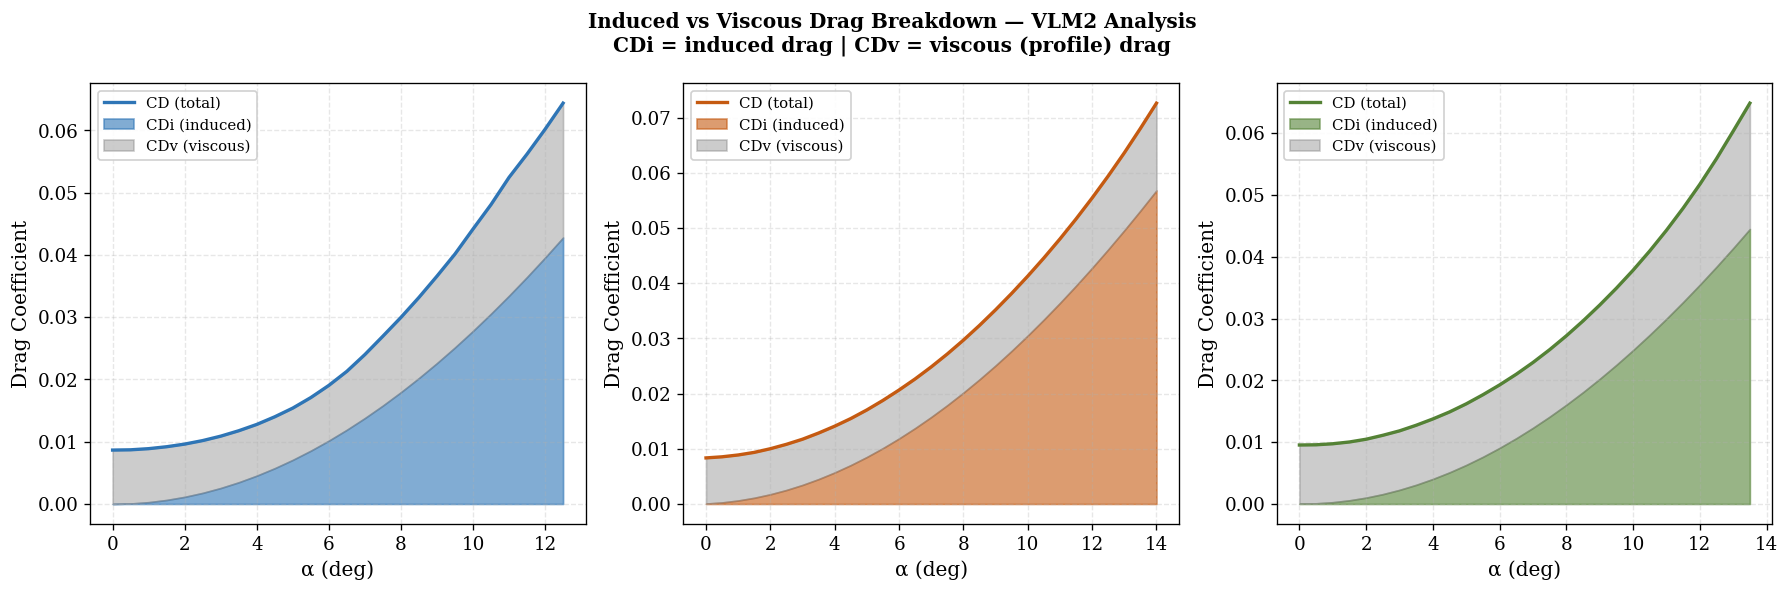

In [12]:
#Initialize figure settings
fig, (ax_wing_a,ax_wing_b,ax_wing_c) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Induced vs Viscous Drag Breakdown — VLM2 Analysis\n'
             'CDi = induced drag | CDv = viscous (profile) drag', 
             fontsize=12, fontweight='bold')

# Only positive CL range for clarity
wing_a_pos = wing_a[wing_a['alpha'] >= 0].copy()
wing_b_pos = wing_b[wing_b['alpha'] >= 0].copy()
wing_c_pos = wing_c[wing_c['alpha'] >= 0].copy()
    
# --- Plot Drag profile Wing A ---
ax_wing_a.fill_between(wing_a_pos['alpha'], 0, wing_a_pos['CDi'], 
                alpha=0.6, color='#2E75B6',     label='CDi (induced)')
ax_wing_a.fill_between(wing_a_pos['alpha'], wing_a_pos['CDi'], wing_a_pos['CD'],
                alpha=0.4, color='gray', label='CDv (viscous)')
ax_wing_a.plot(wing_a_pos['alpha'], wing_a_pos['CD'], color= '#2E75B6', linewidth=2, label='CD (total)')

ax_wing_a.set_xlabel('α (deg)')
ax_wing_a.set_ylabel('Drag Coefficient')
ax_wing_a.legend(fontsize=9)

# --- Plot Drag profile Wing B ---
ax_wing_b.fill_between(wing_b_pos['alpha'], 0, wing_b_pos['CDi'], 
                alpha=0.6, color= '#C55A11', label='CDi (induced)')
ax_wing_b.fill_between(wing_b_pos['alpha'], wing_b_pos['CDi'], wing_b_pos['CD'],
                alpha=0.4, color='gray', label='CDv (viscous)')
ax_wing_b.plot(wing_b_pos['alpha'], wing_b_pos['CD'], color= '#C55A11', linewidth=2, label='CD (total)')

ax_wing_b.set_xlabel('α (deg)')
ax_wing_b.set_ylabel('Drag Coefficient')
ax_wing_b.legend(fontsize=9)

# --- Plot Drag profile Wing C ---
ax_wing_c.fill_between(wing_c_pos['alpha'], 0, wing_c_pos['CDi'], 
                alpha=0.6, color='#548235', label='CDi (induced)')
ax_wing_c.fill_between(wing_c_pos['alpha'], wing_c_pos['CDi'], wing_c_pos['CD'],
                alpha=0.4, color='gray', label='CDv (viscous)')
ax_wing_c.plot(wing_c_pos['alpha'], wing_c_pos['CD'], color='#548235', linewidth=2, label='CD (total)')

ax_wing_c.set_xlabel('α (deg)')
ax_wing_c.set_ylabel('Drag Coefficient')
ax_wing_c.legend(fontsize=9)

# Display 
plt.tight_layout()
plt.show()

## 4. Performance Comparison 

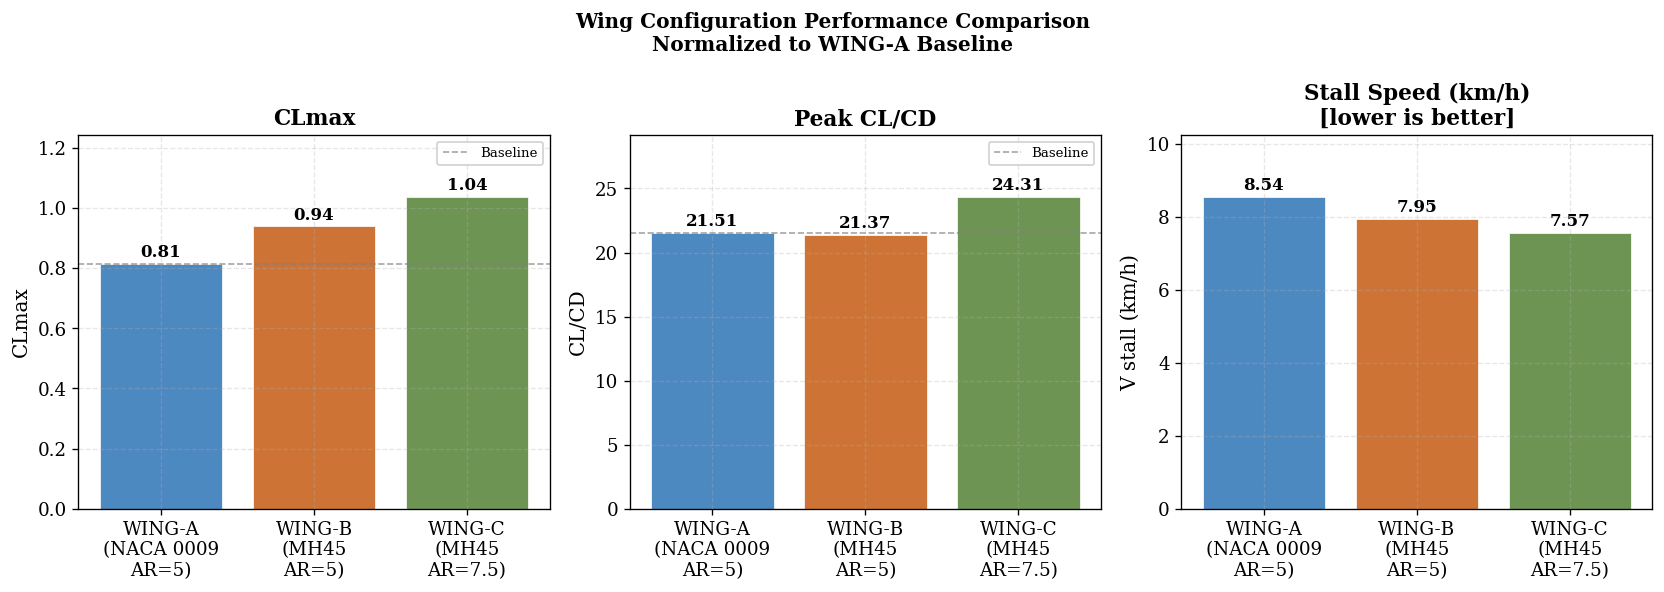

In [24]:
fig, (ax0,ax1,ax2) = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Wing Configuration Performance Comparison\nNormalized to WING-A Baseline', 
             fontsize=12, fontweight='bold')

max_CL_wing_a = wing_a['CL'].max()
max_CL_wing_b = wing_b['CL'].max()
max_CL_wing_c = wing_c['CL'].max()

# Max Lift/Drag Ratio 
CL_CD_max_wing_a = wing_a['CL/CD'].max()
CL_CD_max_wing_b = wing_b['CL/CD'].max()
CL_CD_max_wing_c = wing_c['CL/CD'].max()

# Stall Speed 
rho = 1.225
W_N = 5.89
S_ref = 0.162

# Calculate Stall speed for each wing 
stall_speed_wing_a = np.sqrt(2 * W_N / (rho * S_ref * max_CL_wing_a))
stall_speed_wing_b = np.sqrt(2 * W_N / (rho * S_ref * max_CL_wing_b))
stall_speed_wing_c = np.sqrt(2 * W_N / (rho * S_ref * max_CL_wing_c))

# Plotting parameters 
labels  = ['WING-A\n(NACA 0009\nAR=5)', 'WING-B\n(MH45\nAR=5)', 'WING-C\n(MH45\nAR=7.5)']
cl_max  = [max_CL_wing_a, max_CL_wing_b, max_CL_wing_c]
CL_CD_max   = [CL_CD_max_wing_a, CL_CD_max_wing_b, CL_CD_max_wing_c]
stall_speed = [stall_speed_wing_a,stall_speed_wing_b,stall_speed_wing_c]
plt_colors = ['#2E75B6','#C55A11','#548235']

# ---  Plot Cl max ---
bars0 = ax0.bar(labels, cl_max, color=plt_colors, edgecolor='white', linewidth=0.5, alpha=0.85)

# Initialize Plot settings 
ax0.text(bars0[0].get_x() + bars0[0].get_width()/2, bars0[0].get_height() + 0.01*max(cl_max), f'{cl_max[0]:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax0.text(bars0[1].get_x() + bars0[1].get_width()/2, bars0[1].get_height() + 0.01*max(cl_max), f'{cl_max[1]:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax0.text(bars0[2].get_x() + bars0[2].get_width()/2, bars0[2].get_height() + 0.01*max(cl_max), f'{cl_max[2]:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax0.axhline(cl_max[0], color='gray', linewidth=1, linestyle='--', alpha=0.7, label='Baseline')
ax0.set_title('CLmax')
ax0.set_ylabel('CLmax')
ax0.set_ylim(0, max(cl_max) * 1.2)
ax0.legend(fontsize=8)

# ---  Plot Cl max for each wing ---

bars1 = ax1.bar(labels, CL_CD_max, color=plt_colors, edgecolor='white', linewidth=0.5, alpha=0.85)

ax1.text(bars1[0].get_x() + bars1[0].get_width()/2, bars1[0].get_height() + 0.01*max(CL_CD_max), f'{CL_CD_max [0]:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.text(bars1[1].get_x() + bars1[1].get_width()/2, bars1[1].get_height() + 0.01*max(CL_CD_max), f'{CL_CD_max [1]:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.text(bars1[2].get_x() + bars1[2].get_width()/2, bars1[2].get_height() + 0.01*max(CL_CD_max), f'{CL_CD_max [2]:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.axhline(CL_CD_max[0], color='gray', linewidth=1, linestyle='--', alpha=0.7, label='Baseline')
ax1.set_title('Peak CL/CD')
ax1.set_ylabel('CL/CD')
ax1.set_ylim(0, max(CL_CD_max) * 1.2)
ax1.legend(fontsize=8)

# ---  Plot Stall Speed ---

bars2 = ax2.bar(labels, stall_speed, color=plt_colors, edgecolor='white', linewidth=0.5, alpha=0.85)

ax2.text(bars2[0].get_x() + bars2[0].get_width()/2, bars2[0].get_height() + 0.01*max(stall_speed ), f'{stall_speed[0]:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.text(bars2[1].get_x() + bars2[1].get_width()/2, bars2[1].get_height() + 0.01*max(stall_speed ), f'{stall_speed[1]:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.text(bars2[2].get_x() + bars2[2].get_width()/2, bars2[2].get_height() + 0.01*max(stall_speed ), f'{stall_speed[2]:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('Stall Speed (km/h)\n[lower is better]')
ax2.set_ylabel('V stall (km/h)')
ax2.set_ylim(0, max(stall_speed) * 1.2)

plt.tight_layout()
plt.show()

## 5. 2D vs 3D Cl/CD Performance 

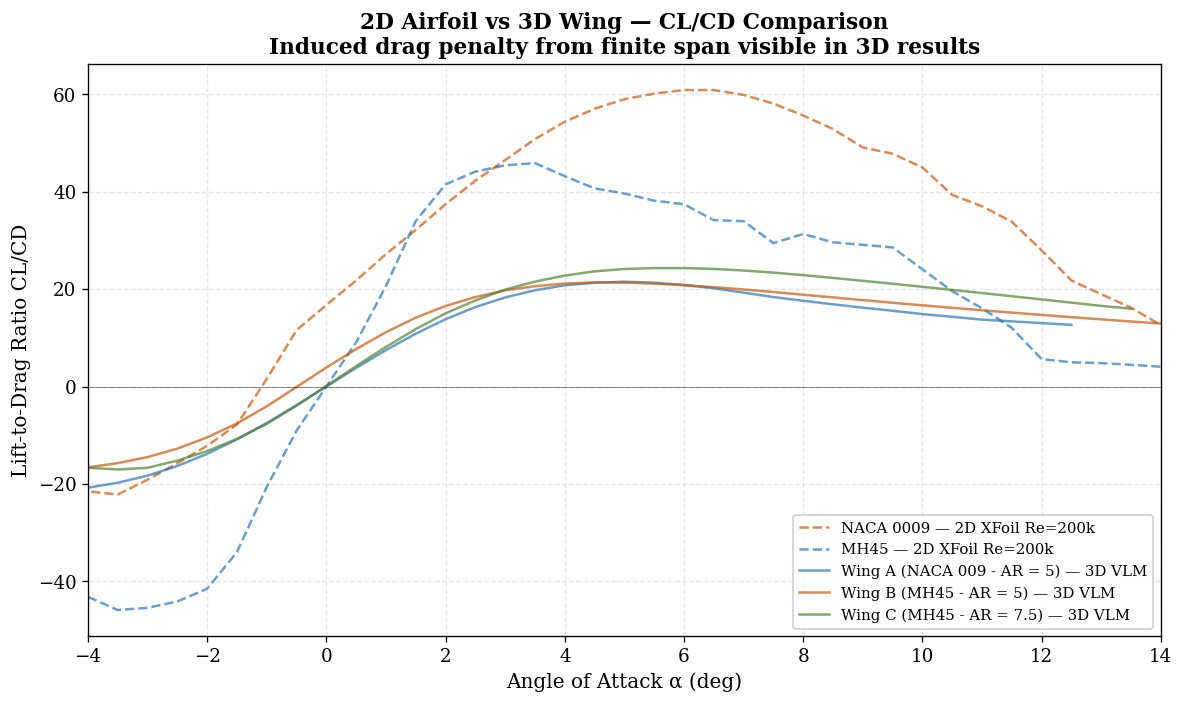

In [27]:
# ─────── Read airfoil csv data ───────────────────────────────────────────────────────────────
mh45_200k     = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\MH45_Re200k.csv')
NACA0009_200k = pd.read_csv(r'C:\Users\colin\OneDrive\Desktop\Xflr5 Processed Data\NACA0009_Re200k.csv')

# Insert Lift/Drag ratio into datasets 
mh45_200k['CL/CD'] = mh45_200k['CL']/mh45_200k['CD']
NACA0009_200k['CL/CD'] = NACA0009_200k['CL']/NACA0009_200k['CD']


fig, ax = plt.subplots(figsize=(10, 6))

# ─────── 2D airfoil CL/CD at Re 200k ────────────────────────────────────────────────────────── 
ax.plot(mh45_200k['alpha'], mh45_200k['CL/CD'], color='#C55A11', linestyle='--', 
        linewidth=1.5,alpha=0.7, label= 'NACA 0009 — 2D XFoil Re=200k')
ax.plot(NACA0009_200k['alpha'], NACA0009_200k['CL/CD'], color='#2E75B6', linestyle='--', 
        linewidth=1.5,alpha=0.7, label='MH45 — 2D XFoil Re=200k')

# ─────── 3D wing CL/CD at Re 200k ─────────────────────────────────────────────────────────────
ax.plot(wing_a['alpha'], wing_a['CL/CD'], color='#2E75B6', linewidth=1.5,
        alpha=0.7, label='Wing A (NACA 009 - AR = 5) — 3D VLM')
ax.plot(wing_b['alpha'], wing_b['CL/CD'], color='#C55A11', linewidth=1.5,
        alpha=0.7, label= 'Wing B (MH45 - AR = 5) — 3D VLM')
ax.plot(wing_c['alpha'], wing_c['CL/CD'], color='#548235', linewidth=1.5,
        alpha=0.7, label=f'Wing C (MH45 - AR = 7.5) — 3D VLM')

# ─────── Plot axes settings ────────────────────────────────────────────────────────────────────
ax.set_xlabel('Angle of Attack α (deg)')
ax.set_ylabel('Lift-to-Drag Ratio CL/CD')
ax.set_title('2D Airfoil vs 3D Wing — CL/CD Comparison\n'
             'Induced drag penalty from finite span visible in 3D results')
ax.axhline(0, color='k', linewidth=0.5, alpha=0.5)
ax.set_xlim(-4, 14)
ax.legend(fontsize=9)

#Display 
plt.tight_layout()
plt.show()

## 5. Summary Data 

In [40]:
# ── Stall ──────────────────────────────────────────────────────────────────
CL_max_wing_a = wing_a['CL'].max()
CL_max_wing_b = wing_b['CL'].max()
CL_max_wing_c = wing_c['CL'].max()

CL_max_wing_a_idx = wing_a['CL'].idxmax()
CL_max_wing_b_idx = wing_b['CL'].idxmax()
CL_max_wing_c_idx = wing_c['CL'].idxmax()

alpha_CLmax_a = wing_a.loc[CL_max_wing_a_idx, 'alpha']
alpha_CLmax_b = wing_b.loc[CL_max_wing_b_idx, 'alpha']
alpha_CLmax_c = wing_c.loc[CL_max_wing_c_idx, 'alpha']

# ── Parameters ─────────────────────────────────────────────────────────────
rho      = 1.225
W_N      = 5.89
S_ref_a  = 0.162
S_ref_b  = 0.162
S_ref_c  = 0.147
v_cruise = 22

# ── Cruise CL ──────────────────────────────────────────────────────────────
cl_req_wing_a = W_N / (0.5 * rho * v_cruise**2 * S_ref_a)
cl_req_wing_b = W_N / (0.5 * rho * v_cruise**2 * S_ref_b)
cl_req_wing_c = W_N / (0.5 * rho * v_cruise**2 * S_ref_c)

cruise_AoA_a = np.interp(cl_req_wing_a, wing_a['CL'], wing_a['alpha'])
cruise_AoA_b = np.interp(cl_req_wing_b, wing_b['CL'], wing_b['alpha'])
cruise_AoA_c = np.interp(cl_req_wing_c, wing_c['CL'], wing_c['alpha'])

# ── Drag ───────────────────────────────────────────────────────────────────
Cd_min_a = wing_a['CD'].min()
Cd_min_b = wing_b['CD'].min()
Cd_min_c = wing_c['CD'].min()

CD_i_wing_a = np.interp(cl_req_wing_a, wing_a['CL'], wing_a['CDi'])
CD_i_wing_b = np.interp(cl_req_wing_b, wing_b['CL'], wing_b['CDi'])
CD_i_wing_c = np.interp(cl_req_wing_c, wing_c['CL'], wing_c['CDi'])

CD_v_wing_a = np.interp(cl_req_wing_a, wing_a['CL'], wing_a['CDv'])
CD_v_wing_b = np.interp(cl_req_wing_b, wing_b['CL'], wing_b['CDv'])
CD_v_wing_c = np.interp(cl_req_wing_c, wing_c['CL'], wing_c['CDv'])

# ── CL/CD max ──────────────────────────────────────────────────────────────
CL_CD_max_a = wing_a['CL/CD'].max()
CL_CD_max_b = wing_b['CL/CD'].max()
CL_CD_max_c = wing_c['CL/CD'].max()

CL_CD_max_wing_a_idx = wing_a['CL/CD'].idxmax()
CL_CD_max_wing_b_idx = wing_b['CL/CD'].idxmax()
CL_CD_max_wing_c_idx = wing_c['CL/CD'].idxmax()

alpha_CL_CD_max_a = wing_a.loc[CL_CD_max_wing_a_idx, 'alpha']
alpha_CL_CD_max_b = wing_b.loc[CL_CD_max_wing_b_idx, 'alpha']
alpha_CL_CD_max_c = wing_c.loc[CL_CD_max_wing_c_idx, 'alpha']

# ── Cm at cruise ───────────────────────────────────────────────────────────
cm_AoA_a = np.interp(cruise_AoA_a, wing_a['alpha'], wing_a['Cm'])
cm_AoA_b = np.interp(cruise_AoA_b, wing_b['alpha'], wing_b['Cm'])
cm_AoA_c = np.interp(cruise_AoA_c, wing_c['alpha'], wing_c['Cm'])

# ── Stall speed ────────────────────────────────────────────────────────────
V_stall_a = np.sqrt((2 * W_N) / (rho * S_ref_a * CL_max_wing_a)) * 3.6
V_stall_b = np.sqrt((2 * W_N) / (rho * S_ref_b * CL_max_wing_b)) * 3.6
V_stall_c = np.sqrt((2 * W_N) / (rho * S_ref_c * CL_max_wing_c)) * 3.6

# ── Induced drag fraction ──────────────────────────────────────────────────
CDi_frac_a = CD_i_wing_a / (CD_i_wing_a + CD_v_wing_a)
CDi_frac_b = CD_i_wing_b / (CD_i_wing_b + CD_v_wing_b)
CDi_frac_c = CD_i_wing_c / (CD_i_wing_c + CD_v_wing_c)

# ── Metrics ────────────────────────────────────────────────────────────────
metrics = [
    ('CLmax',          'CLmax',                       '{:.3f}',  CL_max_wing_a,     CL_max_wing_b,     CL_max_wing_c),
    ('alpha_stall',    'Stall AoA (°)',                '{:.1f}',  alpha_CLmax_a,     alpha_CLmax_b,     alpha_CLmax_c),
    ('V_stall_kmh',    'Stall speed (km/h)',           '{:.1f}',  V_stall_a,         V_stall_b,         V_stall_c),
    ('CL_cruise',      'Required CL at cruise',        '{:.4f}',  cl_req_wing_a,     cl_req_wing_b,     cl_req_wing_c),
    ('alpha_cruise',   'Cruise AoA (°)',               '{:.2f}',  cruise_AoA_a,      cruise_AoA_b,      cruise_AoA_c),
    ('CD_min',         'CD minimum',                   '{:.4f}',  Cd_min_a,          Cd_min_b,          Cd_min_c),
    ('CDi_cruise',     'CDi at cruise (induced)',      '{:.4f}',  CD_i_wing_a,       CD_i_wing_b,       CD_i_wing_c),
    ('CDv_cruise',     'CDv at cruise (viscous)',      '{:.4f}',  CD_v_wing_a,       CD_v_wing_b,       CD_v_wing_c),
    ('CDi_fraction',   'Induced drag fraction',        '{:.1%}',  CDi_frac_a,        CDi_frac_b,        CDi_frac_c),
    ('CL_CD_max',      'Peak CL/CD',                  '{:.2f}',  CL_CD_max_a,       CL_CD_max_b,       CL_CD_max_c),
    ('alpha_LD',       'AoA at peak L/D (°)',          '{:.1f}',  alpha_CL_CD_max_a, alpha_CL_CD_max_b, alpha_CL_CD_max_c),
    ('Cm_cruise',      'Cm at cruise AoA',             '{:.4f}',  cm_AoA_a,          cm_AoA_b,          cm_AoA_c),
]

geometry = [
    ('Aspect ratio',    '{:.3f}',  5.0,   5.0,   7.5),
    ('Span (m)',        '{:.3f}',  0.900, 0.900, 1.050),
    ('Root chord (m)',  '{:.3f}',  0.180, 0.180, 0.180),
    ('Tip chord (m)',   '{:.3f}',  0.180, 0.180, 0.100),
    ('Ref. area (m²)',  '{:.3f}',  0.162, 0.162, 0.147),
    ('MAC (m)',         '{:.3f}',  0.180, 0.180, 0.144),
    ('Planform',        'str',     'Rectangular', 'Rectangular', 'Tapered'),
]

# ── Print table ────────────────────────────────────────────────────────────
col_width   = 22
label_width = 30
total_width = label_width + col_width * 3
title       = "3D Wing Configuration Comparison — VLM2 at V = 22.0 m/s"

headers1 = ["WING-A",        "WING-B",    "WING-C"     ]
headers2 = ["NACA0009 AR=5", "MH45 AR=5", "MH45 AR=7.5"]

print()
print(title)
print("=" * total_width)
print(" " * label_width + "".join(f"{h:>{col_width}}" for h in headers1))
print(" " * label_width + "".join(f"{h:>{col_width}}" for h in headers2))

#  Aerodynamic section 
print("-" * total_width)
print("Aerodynamic Performance")
print("-" * total_width)
for _, label, fmt, val_a, val_b, val_c in metrics:
    print(f"{label:<{label_width}}{fmt.format(val_a):>{col_width}}{fmt.format(val_b):>{col_width}}{fmt.format(val_c):>{col_width}}")

#  Geometry section 
print("-" * total_width)
print("Wing Geometry Reference")
print("-" * total_width)
for row in geometry:
    label, fmt, a, b, c = row
    if fmt == 'str':
        print(f"{label:<{label_width}}{a:>{col_width}}{b:>{col_width}}{c:>{col_width}}")
    else:
        print(f"{label:<{label_width}}{fmt.format(a):>{col_width}}{fmt.format(b):>{col_width}}{fmt.format(c):>{col_width}}")

print("=" * total_width)


3D Wing Configuration Comparison — VLM2 at V = 22.0 m/s
                                              WING-A                WING-B                WING-C
                                       NACA0009 AR=5             MH45 AR=5           MH45 AR=7.5
------------------------------------------------------------------------------------------------
Aerodynamic Performance
------------------------------------------------------------------------------------------------
CLmax                                          0.815                 0.939                 1.036
Stall AoA (°)                                   12.5                  14.0                  13.5
Stall speed (km/h)                              30.7                  28.6                  28.6
Required CL at cruise                         0.1226                0.1226                0.1352
Cruise AoA (°)                                  1.85                  1.36                  1.72
CD minimum                                    